In [1]:
#1) Elegir un conjunto de parámetros cosmológicos y hacer una corrida con el CAMB para obtener el espectro angular de potencias (C_ell)

#2) Hacer una realización de mapa usando el healpy, con un Nside dado. Cambiar el valor de Nside y comentar los cambios observados en el mapa, manteniendo la misma semilla (seed), para que el mapa tenga un aspecto parecido (sea la misma realización).

#3) Elegir un Nside (por ejemplo, Nside=256) y hacer un histograma de los valores de Temperatura del mapa, es decir, de T(n). Tiene aspecto de distribución gaussiana?

#4) Calcular los momentos angulares de dicho mapa, es decir, los a_lm's. Graficar los histogramas de a_lm, para un ell fijo (tomar algunos valores de referencia y repetir el ejercicio - por ejemplo, ell= 20, 200, 500, 1000)

#5) Calcular el C_ell a partir de mapa con la herramienta anafast, y luego repetir el cálculo a mano, con la fórmula del pseudo-C_ell (es decir, para un dado ell, tomar (Sum_m a_lm)/(2ell+1) ). Comparar los resultados.

#6) Hacer un mapa de foregrounds con el Pysm. Graficarlo. Hacer el histograma de T(n) y mirar su aspecto. Parece una gaussiana?

#Esto quedaba pendiente 

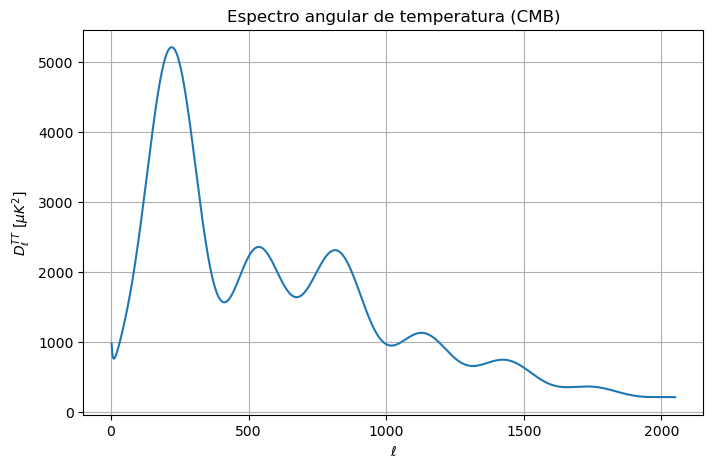

In [44]:
# Importamos las librerías necesarias
import camb                          # Código para calcular espectros cosmológicos
from camb import model, initialpower
import numpy as np                   # Para manejo de arreglos numéricos
import matplotlib.pyplot as plt      # Para graficar

# 1) Definición de parámetros cosmológicos

# Creamos un objeto que contendrá todos los parámetros del modelo
pars = camb.CAMBparams()

# Fijamos parámetros cosmológicos básicos (valores tipo Planck)
pars.set_cosmology(
    H0=67,          # Constante de Hubble hoy (km/s/Mpc)
    ombh2=0.0224,   # Densidad de bariones (Ω_b h^2)
    omch2=0.12      # Densidad de materia oscura fría (Ω_c h^2)
)

# Definimos el espectro primordial de perturbaciones
pars.InitPower.set_params(
    As=2e-9,        # Amplitud de perturbaciones primordiales
    ns=0.965        # Índice espectral (tilt)
)

# 2) Configuración del cálculo

# Le decimos a CAMB hasta qué multipolo ℓ queremos calcular
# ℓ_max ~ resolución angular del espectro
pars.set_for_lmax(
    2000,                      # máximo ℓ
    lens_potential_accuracy=1  # incluye lensing (básico)
)

# 3) Ejecutar CAMB

# Ejecuta el cálculo cosmológico (resuelve ecuaciones de Boltzmann)
results = camb.get_results(pars)

# Obtiene los espectros de potencia del CMB
# CMB_unit='muK' → unidades en microkelvin^2
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK',raw_cl=True)

# 4) Extraer el espectro TT

# 'total' contiene TT, EE, BB y TE
totCL = powers['total']

# Creamos el arreglo de multipolos ℓ
ells = np.arange(totCL.shape[0])

# totCL[:,0] corresponde a TT (temperatura-temperatura)
Cl_TT = totCL[:, 0]

# 5) Graficar el espectro angular

plt.figure(figsize=(8,5))

# Partimos desde ℓ=2 (ℓ=0 y 1 no son físicos para CMB)
plt.plot(ells[2:], ells[2:]*(ells[2:]+1)/(2.*np.pi)*Cl_TT[2:])

plt.xlabel(r'$\ell$')                 # multipolo angular
plt.ylabel(r'$D_\ell^{TT}$ [$\mu K^2$]')  # potencia angular
plt.title("Espectro angular de temperatura (CMB)")

plt.grid(True)
plt.show()

In [40]:
Cl_TT


array([  0.        ,   0.        , 974.20738517, ..., 206.98435883,
       206.81009709, 206.62947352], shape=(2051,))

In [42]:
ells

array([   0,    1,    2, ..., 2048, 2049, 2050], shape=(2051,))

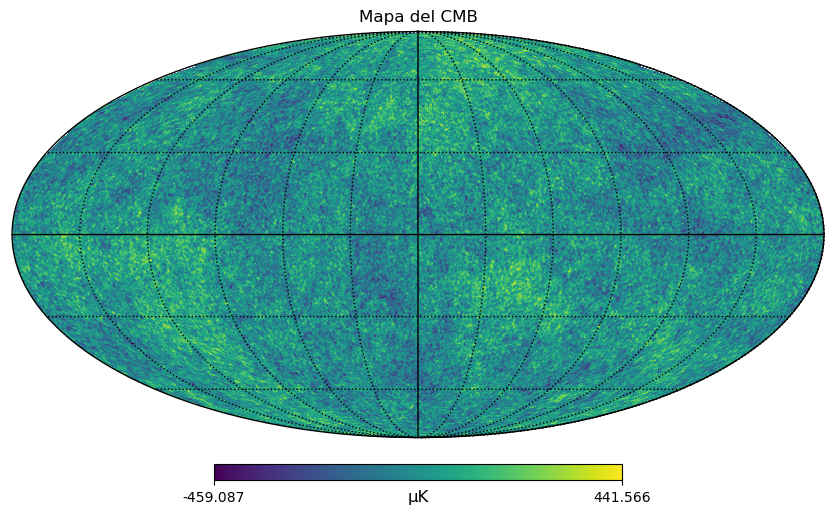

In [45]:
# GENERACIÓN DE MAPA DEL CMB CON HEALPY
#Un mapa del CMB es básicamente una realización aleatoria de ese espectro.

import healpy as hp
# healpy: librería para trabajar con mapas en la esfera (formato HEALPix)

# 1) Definir resolución del mapa

nside = 128  
# Parámetro clave en HEALPix
# Controla la resolución del mapa
#
# Número total de píxeles:
# Npix = 12 * nside^2
#
# Ejemplos:
# nside = 64   → baja resolución
# nside = 128  → media
# nside = 256+ → alta

# 2) Fijar semilla aleatoria

np.random.seed(0)
# Esto asegura que la realización aleatoria sea reproducible
# Es decir, si cambias nside pero mantienes la seed,
# obtendrás "el mismo patrón" pero con distinta resolución

# 3) Usar el espectro C_ell (TT)

cls = totCL[:, 0]
# Este es el C_ell de temperatura que calculaste con CAMB
#
# Contiene la información estadística del mapa:
# NO define un mapa único → define una distribución de posibles mapas


# 4) Generar el mapa del CMB

mapa = hp.synfast(cls, nside=nside, new=True)

# hp.synfast:
# Genera una realización gaussiana del cielo a partir de C_ell
#
# Internamente:
# 1. Genera coeficientes a_lm aleatorios
# 2. Cumpliendo: <|a_lm|^2> = C_ell
# 3. Construye el mapa T(n) usando armónicos esféricos
#
# "new=True" usa la convención moderna de healpy

# 5) Visualizar el mapa

hp.mollview(
    mapa,
    title="Mapa del CMB",
    unit="μK"
)

# mollview:
# Proyección de Mollweide → muestra toda la esfera en 2D

hp.graticule()
# Agrega líneas de coordenadas (longitud/latitud)


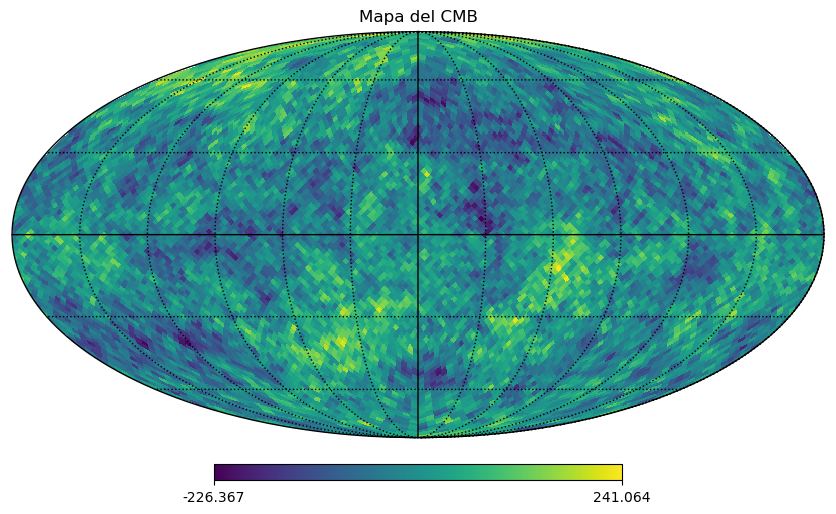

In [46]:
import healpy as hp

nside = 32 #resolucion!
np.random.seed(0)  

cls = totCL[:,0]  # TT

# Crear mapa
mapa = hp.synfast(cls, nside=nside, new=True)

hp.mollview(mapa, title="Mapa del CMB")
hp.graticule()

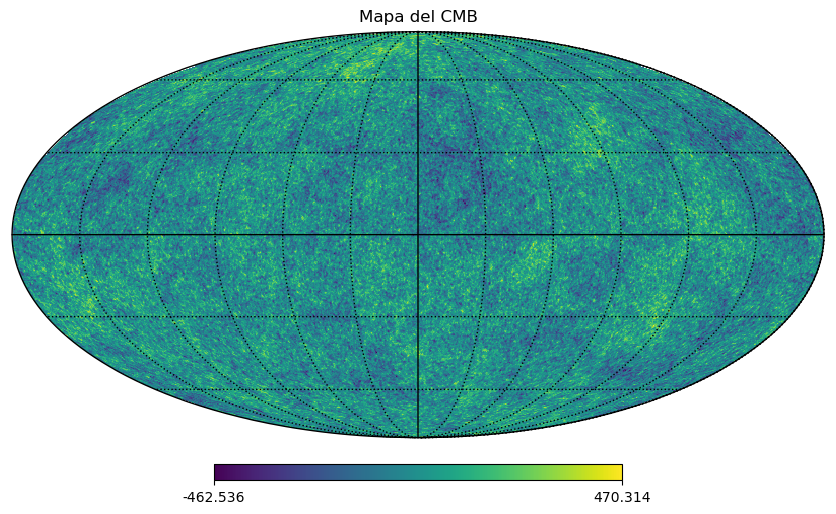

In [47]:
import healpy as hp

nside = 256 #resolucion!
np.random.seed(0)  

cls = totCL[:,0]  # TT

# Crear mapa
mapa = hp.synfast(cls, nside=nside, new=True)

hp.mollview(mapa, title="Mapa del CMB")
hp.graticule()

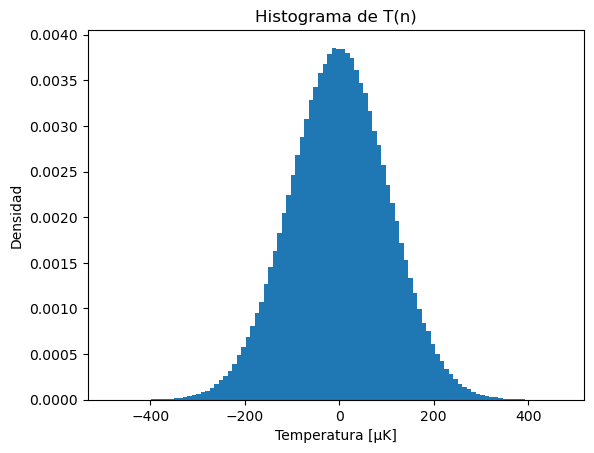

In [48]:
#Histograma de T(n)


# Elegimos resolución fija
nside = 256
np.random.seed(0)

mapa = hp.synfast(cls, nside=nside, new=True)

# Histograma de temperaturas
plt.hist(mapa, bins=100, density=True)

plt.xlabel("Temperatura [μK]")
plt.ylabel("Densidad")
plt.title("Histograma de T(n)")

plt.show()

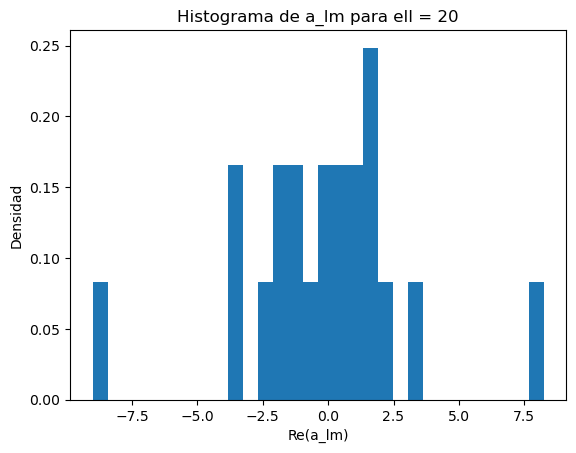

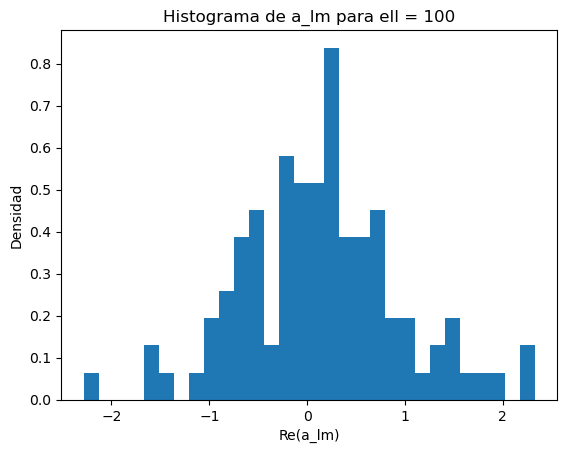

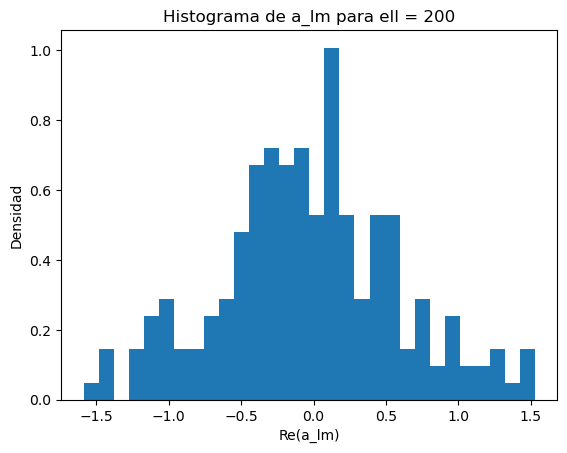

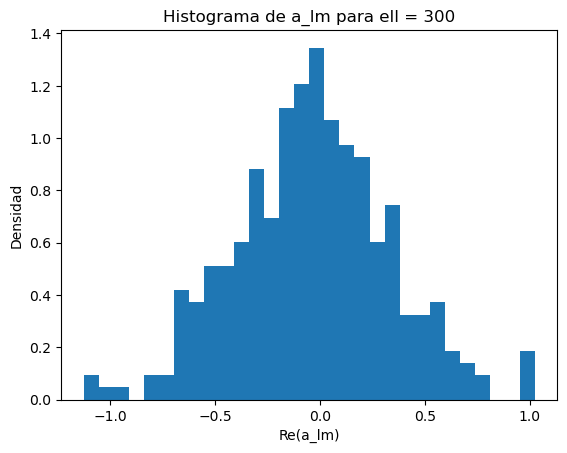

In [49]:
# CÁLCULO DE a_lm Y SUS HISTOGRAMAS

import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
# 1) Convertir mapa → coeficientes armónicos a_lm

alm = hp.map2alm(mapa)

# hp.map2alm:
# Toma el mapa T(n) y calcula los coeficientes a_lm
# Es una transformada en armónicos esféricos

# 2) Obtener lmax (máximo ℓ presente)

lmax = hp.Alm.getlmax(len(alm))

# Esto es necesario porque alm es un vector "aplanado"
# y necesitamos saber cómo se organiza en (ℓ, m)

# 3) Elegir valores de ℓ a estudiar

ells_a_estudiar = [20, 100, 200, 300]
# 4) Loop sobre ℓ

for ell in ells_a_estudiar:

    valores_alm = []  # aquí guardaremos los a_lm para este ℓ

    # 5) Recorrer todos los m posibles para este ℓ
    
    for m in range(ell + 1):
        # m va desde 0 hasta ℓ

        # Obtener índice dentro del array alm
        idx = hp.Alm.getidx(lmax, ell, m)

        # Extraer el valor complejo a_lm
        alm_val = alm[idx]

        # Guardamos SOLO la parte real (se puede usar imag también)
        valores_alm.append(np.real(alm_val))

    # 6) Graficar histograma

    plt.hist(valores_alm, bins=30, density=True)

    plt.xlabel("Re(a_lm)")
    plt.ylabel("Densidad")
    plt.title(f"Histograma de a_lm para ell = {ell}")

    plt.show()

In [50]:
# Calcular C_ell desde el mapa
# MÉTODO 1: USANDO HEALPY (anafast)
# hp.anafast:
# calcula directamente el espectro de potencia C_ell desde el mapa

cl_map = hp.anafast(mapa)

# cl_map[ell] = C_ell

In [51]:
# MÉTODO 2: CÁLCULO MANUAL DESDE a_lm

# Obtener coeficientes a_lm
alm = hp.map2alm(mapa)

# Obtener el ℓ máximo
lmax = hp.Alm.getlmax(len(alm))

# Lista donde guardaremos C_ell
cl_manual = []

# Loop sobre ℓ

for ell in range(lmax + 1):

    suma = 0  # aquí acumulamos |a_lm|^2

    # m = 0 (caso especial)
    
    idx = hp.Alm.getidx(lmax, ell, 0)
    alm_val = alm[idx]
    
    suma += np.abs(alm_val)**2  # NO lleva factor 2

    # m = 1 hasta ℓ

    for m in range(1, ell + 1):

        idx = hp.Alm.getidx(lmax, ell, m)
        alm_val = alm[idx]

        # IMPORTANTE:
        # multiplicamos por 2 porque faltan los m negativos
        suma += 2 * np.abs(alm_val)**2

    # Normalización final

    cl = suma / (2*ell + 1)

    cl_manual.append(cl)

# Convertimos a array
cl_manual = np.array(cl_manual)

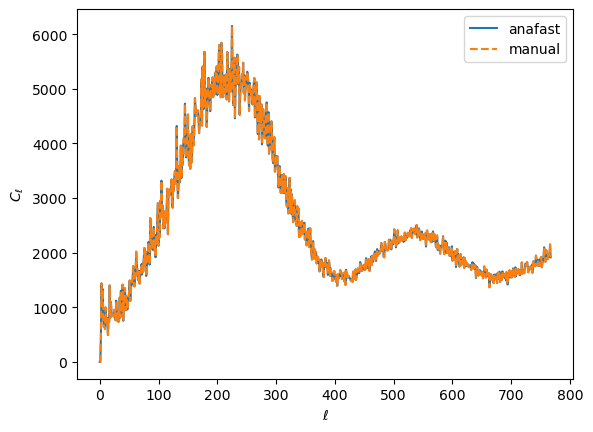

In [34]:
plt.plot(cl_map, label="anafast")
plt.plot(cl_manual, '--', label="manual")

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend()
plt.show()


In [52]:
import pysm3
import pysm3.units as u
#El cielo real NO es solo CMB
# señales que NO son el CMB

nside = 256

# Modelo simple de foregrounds (polvo galáctico) d1
sky = pysm3.Sky(nside=nside, preset_strings=["d1"])

# frecuencia (ej: 100 GHz)
map_fg = sky.get_emission(100 * u.GHz) #¿Cómo se ve el cielo a 100 GHz considerando solo polvo?

# tomar solo temperatura
map_fg = map_fg[0].value

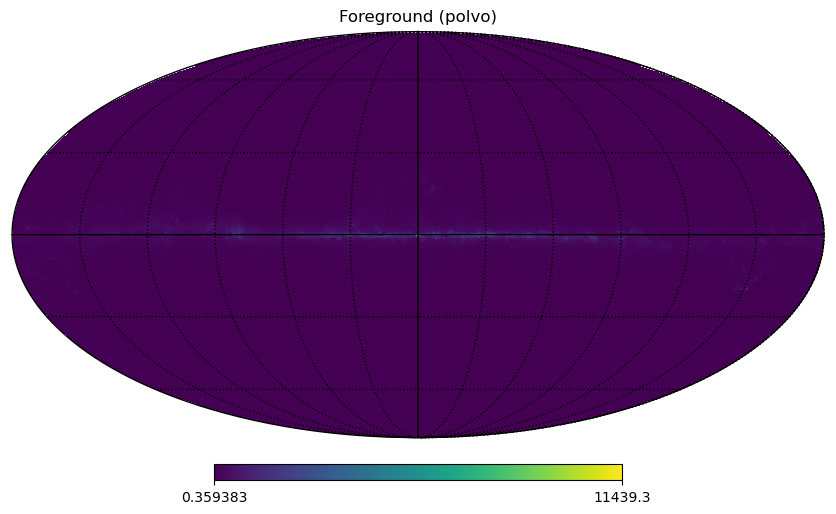

In [53]:
hp.mollview(map_fg, title="Foreground (polvo)")
hp.graticule()

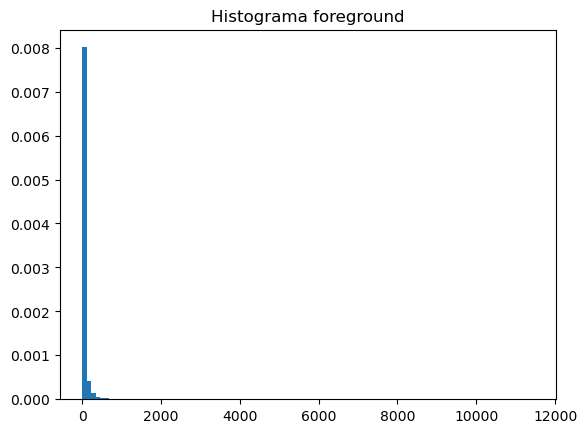

In [54]:
#¿Cómo se distribuyen los valores de temperatura?
plt.hist(map_fg, bins=100, density=True)
plt.title("Histograma foreground")
plt.show()